#Predicting Loan Approval Using Machine Learning

*A clean, modular pipeline for predicting loan approval status
using a Random Forest classifier.*

*The data was obtained from kaggle*

In [ ]:
from datascience import * #
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer #
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split #
%matplotlib inline #
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import seaborn as sns

# Data Cleaning

In [ ]:
LoanData= pd.read_excel('/content/database.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
LoanData

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10312,25,male,Master,80736,5,OWN,5000,MEDICAL,12.53,0.06,4,707,No,0
10313,26,female,Bachelor,80625,2,MORTGAGE,10000,VENTURE,7.88,Nan,4,630,Yes,0
10314,22,male,Bachelor,80470,1,MORTGAGE,15000,EDUCATION,13.48,0.19,2,648,No,0
10315,23,male,Bachelor,118090,0,RENT,9600,DEBTCONSOLIDATION,10.37,0.08,3,575,Yes,0


In [ ]:
#This method removes duplicate rows from the DataFrame.
LoanData = LoanData.drop_duplicates()

In [ ]:
LoanData

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10312,25,male,Master,80736,5,OWN,5000,MEDICAL,12.53,0.06,4,707,No,0
10313,26,female,Bachelor,80625,2,MORTGAGE,10000,VENTURE,7.88,Nan,4,630,Yes,0
10314,22,male,Bachelor,80470,1,MORTGAGE,15000,EDUCATION,13.48,0.19,2,648,No,0
10315,23,male,Bachelor,118090,0,RENT,9600,DEBTCONSOLIDATION,10.37,0.08,3,575,Yes,0


In [ ]:
# We dropped the unwanted coulmns
LoanData.drop(["person_age","person_education","person_emp_exp","loan_amnt","person_home_ownership","loan_intent","cb_person_cred_hist_length","person_gender","loan_int_rate"],inplace=True,axis=1)

<ipython-input-12-43fb8f12ed74>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(["person_age","person_education","person_emp_exp","loan_amnt","person_home_ownership","loan_intent","cb_person_cred_hist_length","person_gender","loan_int_rate"],inplace=True,axis=1)


In [ ]:
LoanData

,person_income,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,71948,0.49,561,No,1
1,12282,0.08,504,Yes,0
2,12438,0.44,635,No,1
3,79753,0.44,675,No,1
4,66135,0.53,586,No,1
...,...,...,...,...,...
10312,80736,0.06,707,No,0
10313,80625,Nan,630,Yes,0
10314,80470,0.19,648,No,0
10315,118090,0.08,575,Yes,0


In [ ]:
# missing_values=np.nan: Specifies that the imputer should look for missing values in the dataset that are represented by np.nan (which is the representation for missing or "Not a Number" values in numpy).
LoanData = LoanData.replace('Nan',np.nan)

# Change the name of our target varible to 'loan_approval'
LoanData = LoanData.rename(columns={'loan_status': 'loan_approval'})

## dropna(): This method is used to remove rows (or columns) that contain missing values (NaN) from a pandas DataFrame.
LoanData.dropna(inplace=True)

<ipython-input-14-76a95c53482e>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('Nan',np.nan)


In [ ]:
LoanData

,person_income,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_approval
0,71948.0,0.49,561,No,1
1,12282.0,0.08,504,Yes,0
2,12438.0,0.44,635,No,1
3,79753.0,0.44,675,No,1
4,66135.0,0.53,586,No,1
...,...,...,...,...,...
10311,80452.0,0.11,588,No,0
10312,80736.0,0.06,707,No,0
10314,80470.0,0.19,648,No,0
10315,118090.0,0.08,575,Yes,0


In [ ]:
# .str.strip(): This is a pandas string method used to remove leading and trailing whitespace characters from each value in 'previous_loan_defaults_on_file' column
LoanData['previous_loan_defaults_on_file']=LoanData['previous_loan_defaults_on_file'].str.strip()

In [ ]:
LoanData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10304 entries, 0 to 10316
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_income                   10304 non-null  float64
 1   loan_percent_income             10304 non-null  float64
 2   credit_score                    10304 non-null  int64  
 3   previous_loan_defaults_on_file  10304 non-null  object 
 4   loan_approval                   10304 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 483.0+ KB


In [ ]:
# .uniqe: Identifies unique values in the 'previous_loan_defaults_on_file' column
LoanData['previous_loan_defaults_on_file'].unique()

array(['No', 'Yes', 'no', 'yes'], dtype=object)

In [ ]:
LoanData['previous_loan_defaults_on_file']=LoanData['previous_loan_defaults_on_file'].replace('no','No')
LoanData['previous_loan_defaults_on_file']=LoanData['previous_loan_defaults_on_file'].replace('yes','Yes')

In [ ]:
LoanData['previous_loan_defaults_on_file'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# .head: shows you the first 5 rows of the Dataframe
LoanData.head()

,person_income,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_approval
0,71948.0,0.49,561,No,1
1,12282.0,0.08,504,Yes,0
2,12438.0,0.44,635,No,1
3,79753.0,0.44,675,No,1
4,66135.0,0.53,586,No,1


In [ ]:
# This line of code is used to map or convert categorical values in the previous_loan_defaults_on_file column of the data DataFrame to numerical values.
# 'No' is replaced by 0.
# 'Yes' is replaced by 1.
LoanData['previous_loan_defaults_on_file']= LoanData['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

In [ ]:
LoanData.head()

,person_income,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_approval
0,71948.0,0.49,561,0,1
1,12282.0,0.08,504,1,0
2,12438.0,0.44,635,0,1
3,79753.0,0.44,675,0,1
4,66135.0,0.53,586,0,1
...,...,...,...,...,...
10311,80452.0,0.11,588,0,0
10312,80736.0,0.06,707,0,0
10314,80470.0,0.19,648,0,0
10315,118090.0,0.08,575,1,0


In [ ]:
#The new feature
def calculate_risk_score(row):
    score = 0

    score += 1 if row['credit_score'] > 700:
        score += 1
    else:
        score -= 1

    score += 1 if row['loan_percent_income'] < 0.4:
        score += 1
    else:
        score -= 1

    score += 1 if row['previous_loan_defaults_on_file'] == 0:
        score += 1
    else:
        score -= 1

    return score

LoanData['risk_score'] = LoanData.apply(calculate_risk_score, axis=1)

In [ ]:
LoanData.head()

,person_income,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_approval,risk_score
0,71948.0,0.49,561,0,1,1
1,12282.0,0.08,504,1,0,-1
2,12438.0,0.44,635,0,1,1
3,79753.0,0.44,675,0,1,1
4,66135.0,0.53,586,0,1,1


In [ ]:
# This line is used for outlier detection and removal based on the Z-score method.
out_list = ['person_income', 'loan_percent_income', 'credit_score', 'risk_score']
LoanData = LoanData[(np.abs(stats.zscore(data[out_list]))<3).all(axis=1)]

In [ ]:
LoanData.head()

# Modeling and Testing

In [ ]:
# We defined the features (X) and target (y)
X = LoanData[['person_income', 'loan_percent_income', 'credit_score', 'risk_score']]
y = LoanData['loan_approval']

In [ ]:
# We split the data for the testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(3475, 4)
(869, 4)


In [ ]:
# Random Forest is a great choice because it can handle complex data with many features,
# is less sensitive to noise and outliers, and provides good accuracy.
# It's easy to use and works well with classification tasks.
# It helps identify the most important factors for decision-making and,
# is less likely to overfit compared to a single decision tree.

rf_model = RandomForestClassifier(n_estimators=40, max_depth=7, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)
print(rf_model)

RandomForestClassifier(max_depth=7, min_samples_split=10, n_estimators=40,
                       random_state=42)


In [ ]:
# Predict the results on the test set
y_pred = rf_model.predict(X_test)

# ((predictions)) vs (actual values)
print(classification_report(y_test, y_pred))
# Calculate the metrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.0f}" , "%")
precession = classification_report(y_test, y_pred)
print(f"Precession: {precession * 100:.0f}","%")
recall = classification_report(y_test, y_pred)
print(f"Recall: {recall * 100:.0f}","%")


Accuracy: 85 %


In [ ]:
x_pred = rf_model.predict(X_train)
accuracy = accuracy_score(y_train, x_pred)
print(f"Accuracy: {accuracy * 100:.0f}" , "%")

Accuracy: 87 %


# Visualizition

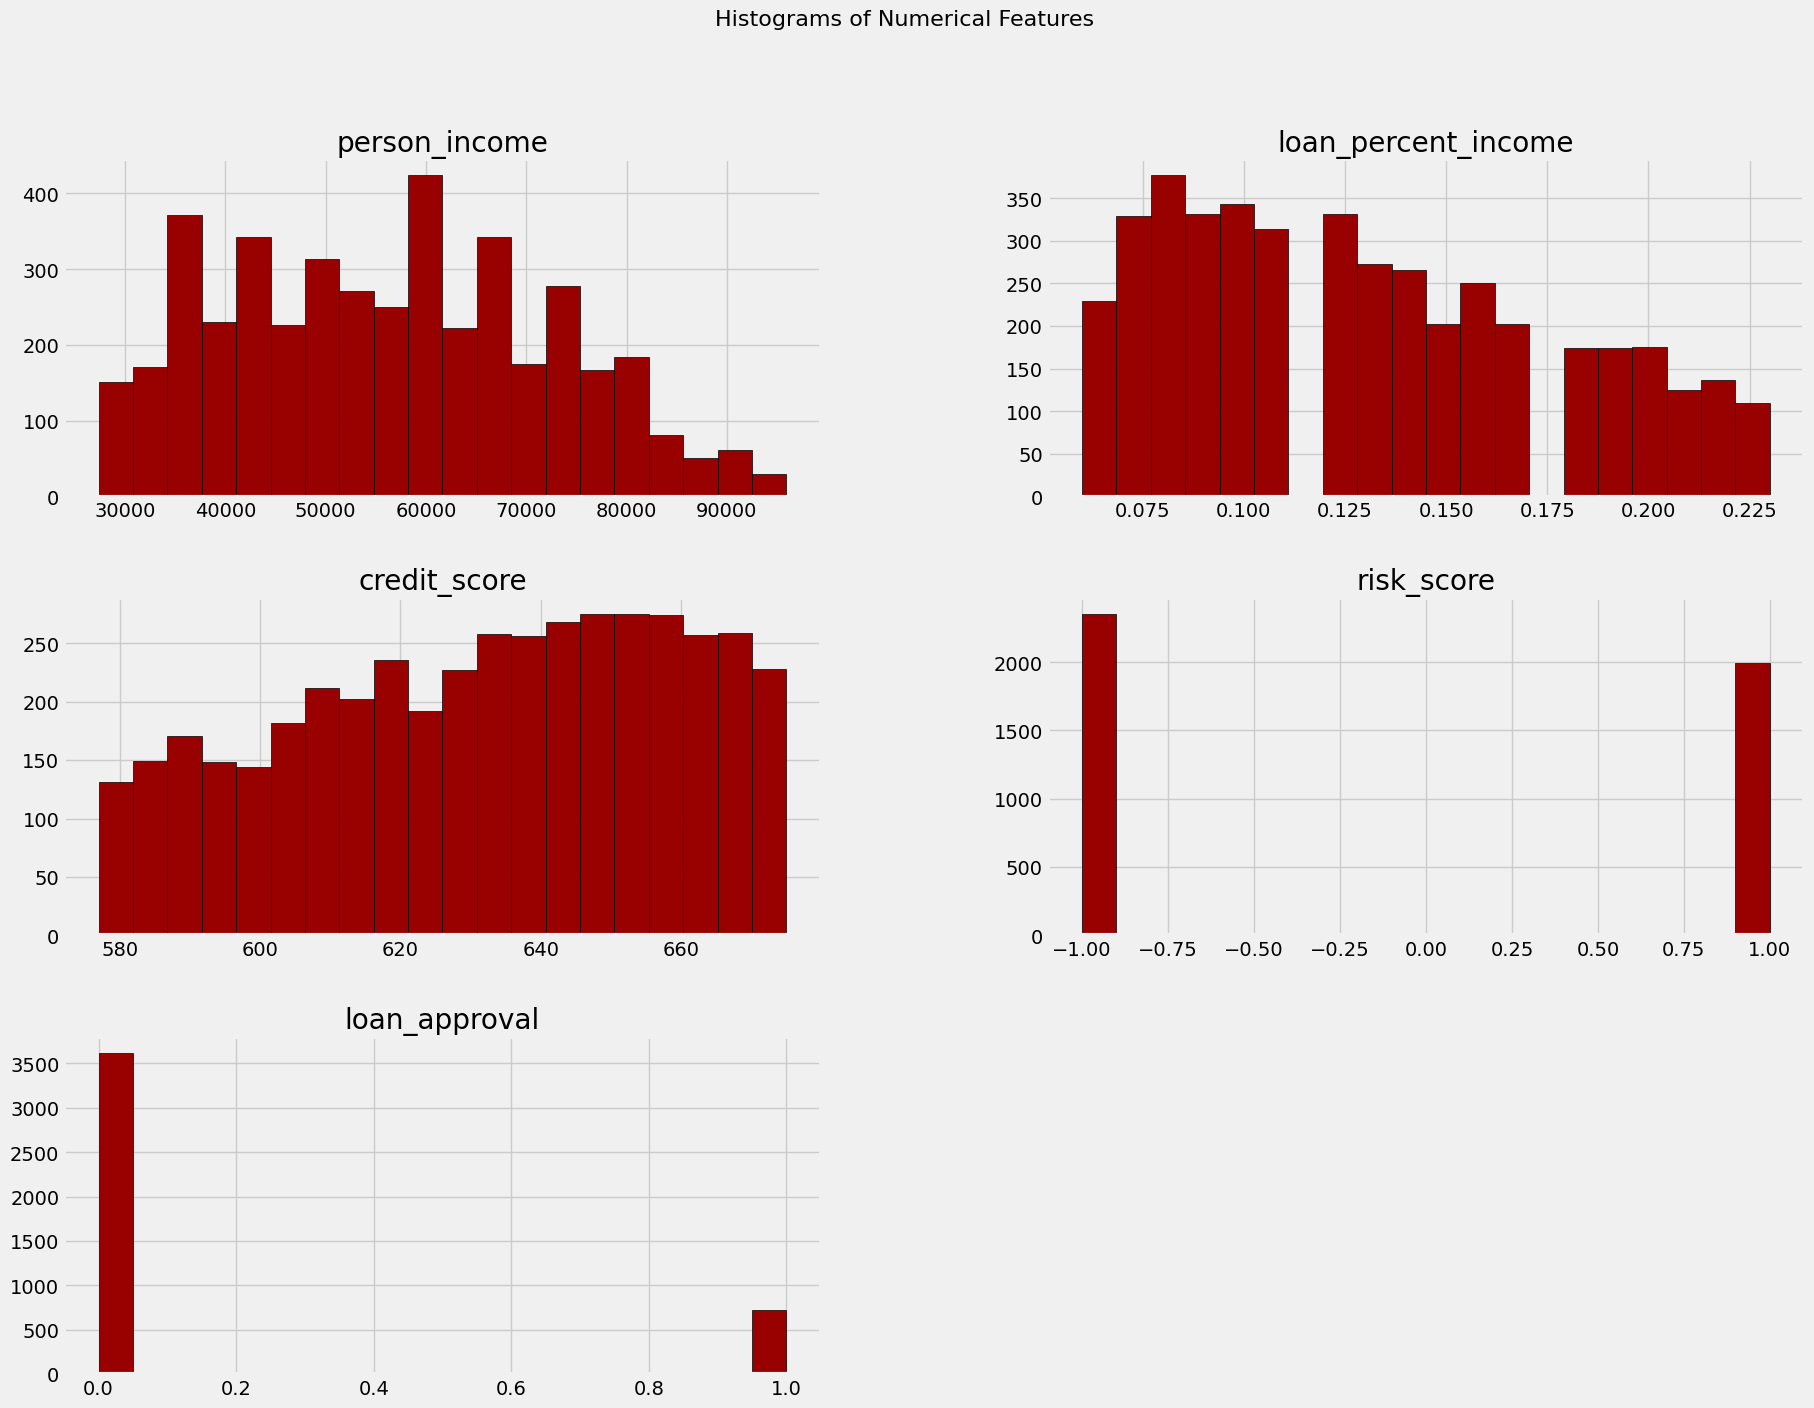

In [ ]:
# histogram
LoanData[['person_income', 'loan_percent_income', 'credit_score', 'risk_score','loan_approval']].hist(bins=20, figsize=(20, 15), color='#990000', edgecolor='black')
plots.suptitle('Histograms of Numerical Features', fontsize=16)
plots.show()

<Figure size 1200x600 with 0 Axes>

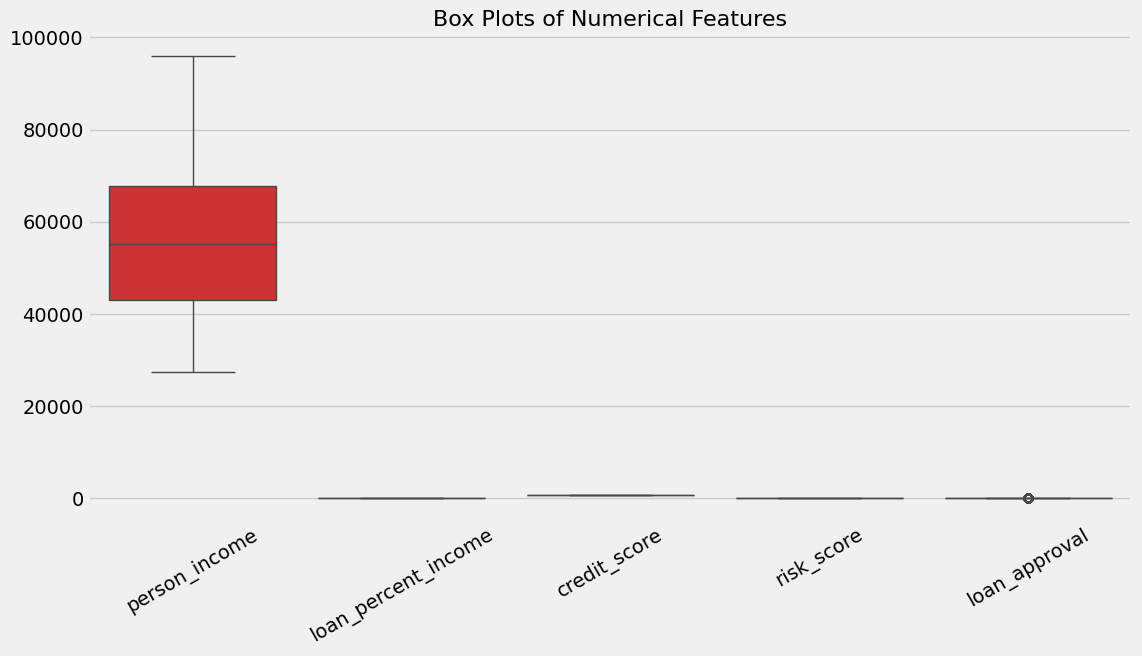

In [ ]:
#Box-blot
plots.figure(figsize=(12, 6))
# Set the figure size (width, height) in inches
plots.figure(figsize=(12, 6))

# Plot the Box Plot using Seaborn
sns.boxplot(data[['person_income', 'loan_percent_income', 'credit_score', 'risk_score','loan_approval']], palette="Set1")

# Add a title to the plot
plots.title('Box Plots of Numerical Features', fontsize=16)
plots.xticks(rotation=30)
# Display the plot
plots.show()

<ipython-input-35-a4b8df16bb90>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[columns] = data[columns].apply(pd.to_numeric, errors='coerce')
<ipython-input-35-a4b8df16bb90>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['income_bins'] = pd.cut(data['person_income'], bins=10) # Dividing into 10 categories
<ipython-input-35-a4b8df16bb90>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fa

Text(0, 0.5, 'Count')

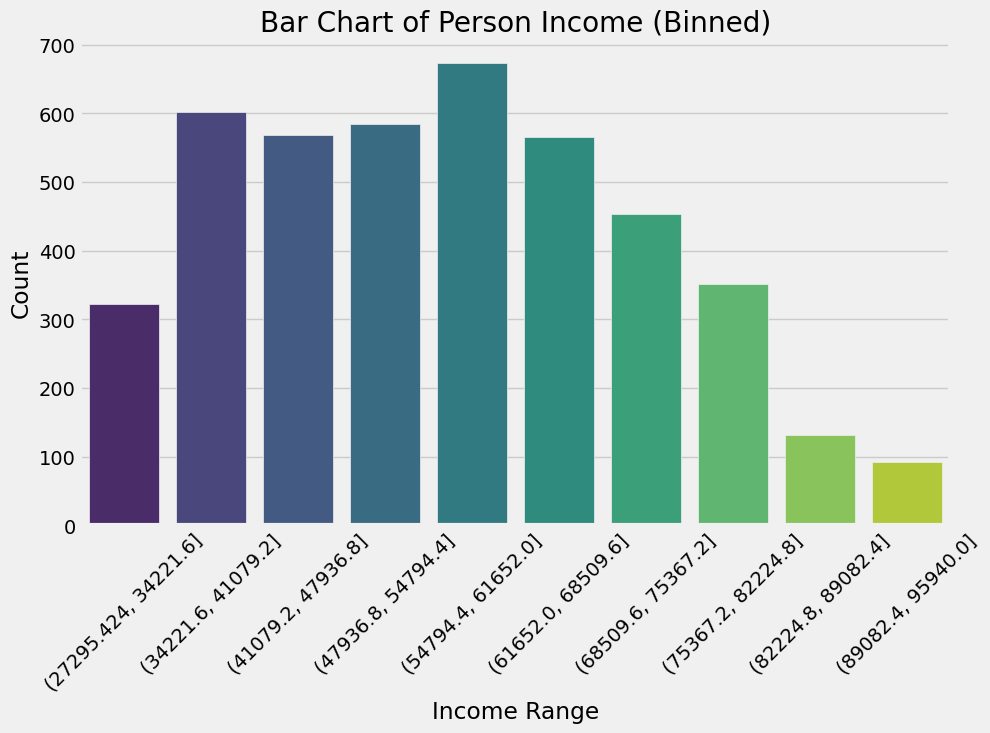

In [ ]:
columns = ['person_income', 'loan_percent_income', 'credit_score', 'loan_approval']
data[columns] = data[columns].apply(pd.to_numeric, errors='coerce')
data['income_bins'] = pd.cut(data['person_income'], bins=10) # Dividing into 10 categories

# Plotting the chart based on categories
plots.figure(figsize=(10, 6))
sns.countplot(x='income_bins', data=data, palette='viridis')
plots.title('Bar Chart of Person Income (Binned)')
plots.xticks(rotation=45)  # Rotate labels on the x-axis
plots.xlabel('Income Range')
plots.ylabel('Count')

In [ ]:
#Analyze the central tendencies of numerical features
columns = ['person_income', 'loan_percent_income', 'credit_score', 'risk_score']
# Mean
mean_values = np.nanmean(data[columns], axis=0)

# Median
median_values = np.nanmedian(data[columns], axis=0)

# Mode (mode is tricky in NumPy, so we use scipy)

mode_values = stats.mode(data[columns], nan_policy='omit').mode[0]

# Variance
var_values = np.nanvar(data[columns], axis=0)

# Standard Deviation
std_values = np.nanstd(data[columns], axis=0)

In [ ]:
print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)
print("\nVariance:\n", var_values)
print("\nStandard Deviation:\n", std_values)

Mean:
 [  5.61887099e+04   1.29831952e-01   6.31448204e+02  -8.33333333e-02]

Median:
 [  5.52505000e+04   1.20000000e-01   6.34000000e+02  -1.00000000e+00]

Mode:
 29937.0

Variance:
 [  2.52764311e+08   2.26302425e-03   7.26091240e+02   9.93055556e-01]

Standard Deviation:
 [  1.58985632e+04   4.75712544e-02   2.69460802e+01   9.96521729e-01]


Text(0, 0.5, 'Credit Score')

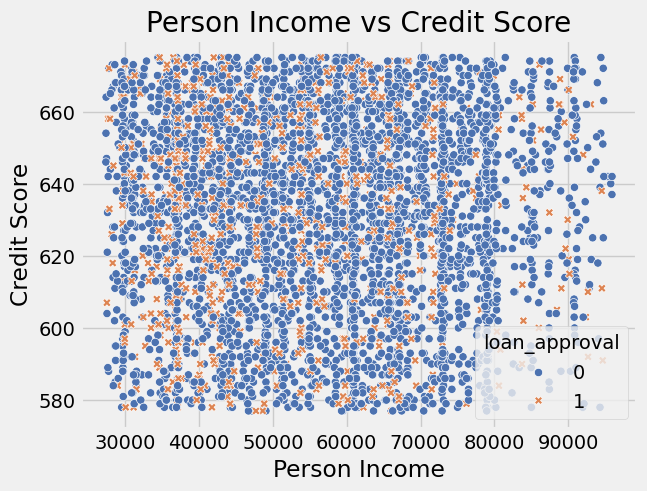

In [ ]:
# Scatter plot: person_income vs credit_score
# Seaborn  used to create the scatter.
# hue='loan_approval': used to color the points based on the 'loan_approval' column.
# style='loan_approval':used to give different styles to points based on loan approval status.
# palette='deep': sets the color palette for the different loan approval statuses.
sns.scatterplot(data=data, x='person_income', y='credit_score', hue='loan_approval', style='loan_approval', palette='deep')
plots.title('Person Income vs Credit Score')
plots.xlabel('Person Income')
plots.ylabel('Credit Score')

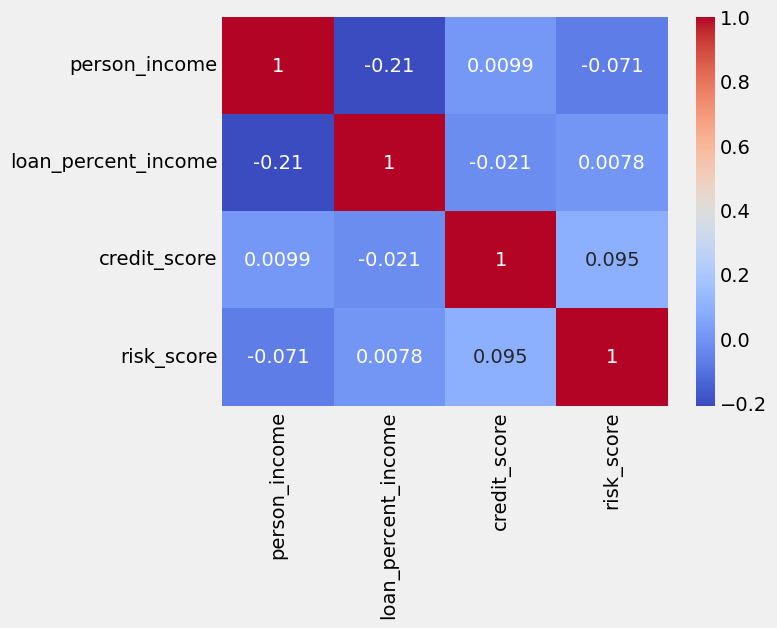

In [ ]:
#create heatmap visualization of correlation matrix.
# alculates correlation between all selected columns.
# cool colors (blue) for negative correlations.
# warm colors (red) for positive correlations.
correlation_matrix = data[['person_income', 'loan_percent_income', 'credit_score', 'risk_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plots.show()